# Creating a csv file

In [51]:
import pandas as pd
import random

num_rows = 50
categories = ["Tech", "Education", "Gaming", "Vlog", "Music", "Cooking"]
creators = ["Alice_Stream", "Bob_The_Builder", "Charlie_Tech", "Dana_Cooks", "Echo_Gaming"]

data = []

for i in range(1, num_rows + 1):
    video_type = "Long Form" if i % 2 != 0 else "Short"

    views = random.randint(1000, 1000000)
    likes = int(views * random.uniform(0.01, 0.12))
    duration_min = round(random.uniform(0.5, 25.0), 2)
    rating = round(random.uniform(1.0, 5.0), 1)

    data.append({
        "Video_ID": f"VID_{i:03d}",
        "Type": video_type,
        "Category": random.choice(categories),
        "Creator": random.choice(creators),
        "Views": views,
        "Likes": likes,
        "Duration_Min": duration_min,
        "Rating": rating,
        "Ads_Enabled": random.choice([True, False])
    })

df = pd.DataFrame(data)
df.to_csv("video_data_clean.csv", index=False)
df = pd.read_csv("video_data_clean.csv")
print(df)

   Video_ID       Type   Category          Creator   Views  Likes  \
0   VID_001  Long Form    Cooking      Echo_Gaming  541767  45194   
1   VID_002      Short      Music     Alice_Stream  111729   8783   
2   VID_003  Long Form       Tech     Charlie_Tech  801447  15404   
3   VID_004      Short       Vlog     Alice_Stream  279701   5496   
4   VID_005  Long Form     Gaming      Echo_Gaming  375202  29873   
5   VID_006      Short       Tech  Bob_The_Builder  778851  21445   
6   VID_007  Long Form       Vlog     Alice_Stream  985459  72187   
7   VID_008      Short  Education  Bob_The_Builder  990998  18164   
8   VID_009  Long Form       Vlog  Bob_The_Builder  715923  79876   
9   VID_010      Short  Education     Alice_Stream  134151  15492   
10  VID_011  Long Form     Gaming     Charlie_Tech  407221  11953   
11  VID_012      Short     Gaming       Dana_Cooks  885210  87505   
12  VID_013  Long Form       Vlog       Dana_Cooks  424085  43810   
13  VID_014      Short      Music 

# **EDA**

Infor about dataset

In [52]:
print('Shape of the Dataset', df.shape)
df.info()
df.describe()

Shape of the Dataset (50, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Video_ID      50 non-null     object 
 1   Type          50 non-null     object 
 2   Category      50 non-null     object 
 3   Creator       50 non-null     object 
 4   Views         50 non-null     int64  
 5   Likes         50 non-null     int64  
 6   Duration_Min  50 non-null     float64
 7   Rating        50 non-null     float64
 8   Ads_Enabled   50 non-null     bool   
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 3.3+ KB


,Views,Likes,Duration_Min,Rating
count,50.000000,50.000000,50.000000,50.000000
mean,587513.040000,36569.540000,12.200800,3.140000
std,301914.022789,26218.523584,7.155751,1.255681
min,2890.000000,121.000000,0.680000,1.000000
25%,376970.500000,15426.000000,6.902500,2.000000
50%,568645.000000,31549.000000,10.405000,3.100000
75%,875702.500000,53405.000000,18.962500,4.375000
max,996186.000000,98684.000000,24.870000,5.000000


# Missing and Duplicate Values

In [53]:
print('Missing Values \n', df.isnull().sum())

Missing Values 
 Video_ID        0
Type            0
Category        0
Creator         0
Views           0
Likes           0
Duration_Min    0
Rating          0
Ads_Enabled     0
dtype: int64


# **Visualizing Relationships**

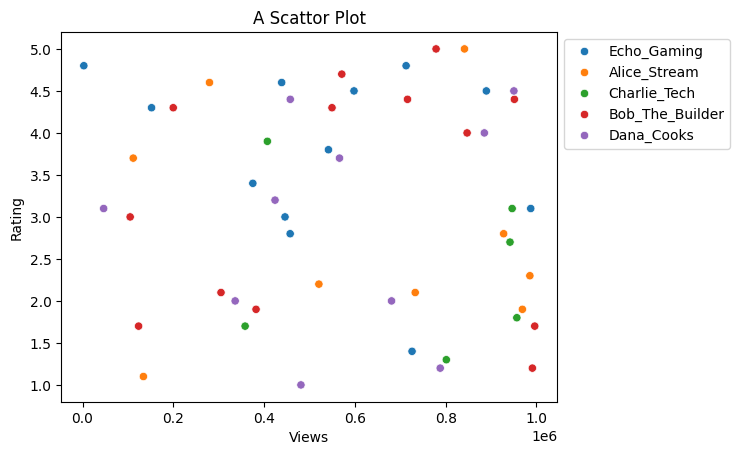

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x = 'Views', y = 'Rating', hue = 'Creator', data=df )
plt.legend(bbox_to_anchor = (1,1), loc=2)
plt.title('A Scattor Plot')
plt.show()

Pair Plot

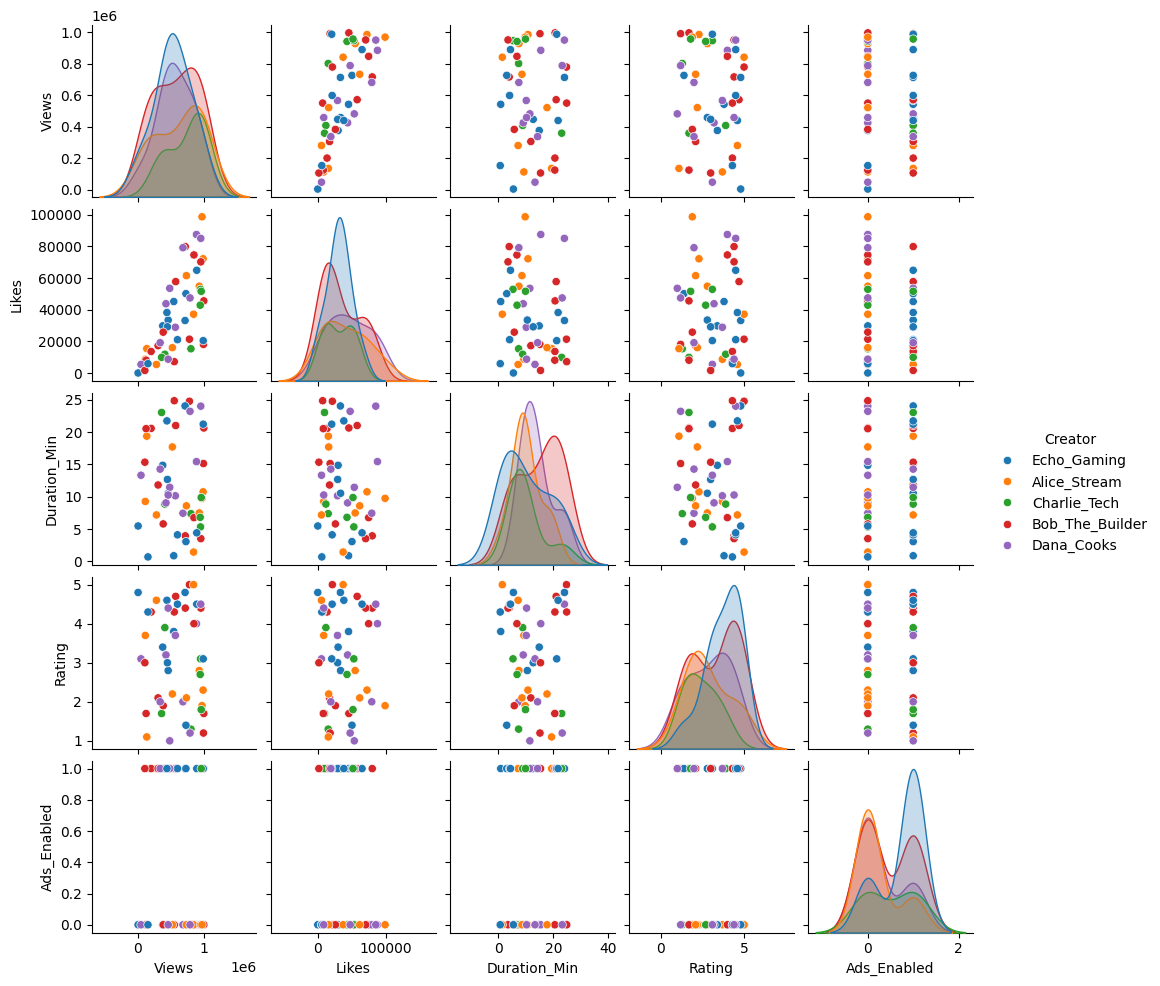

In [55]:
sns.pairplot(df.drop(['Video_ID'], axis=1), hue='Creator', height=2)

# Heatmap with seaborn

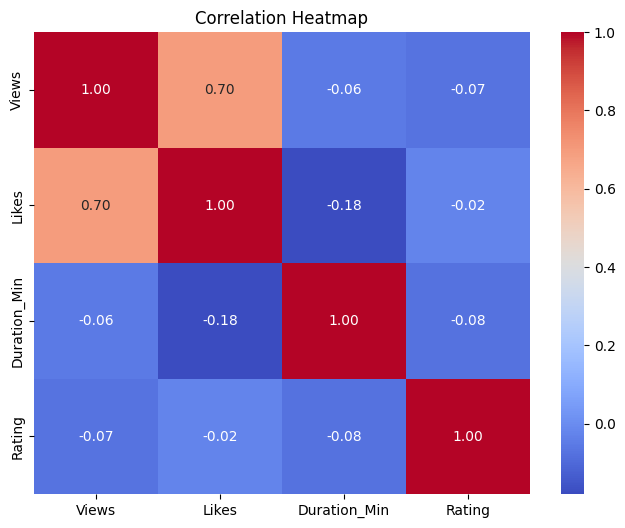

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('video_data_clean.csv')

numeric_values = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_values.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Detect and remove outliers

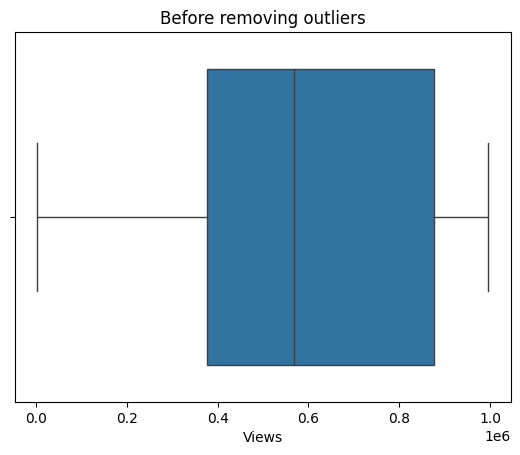

Original Shape (50, 9)
Filtered Shape (50, 9)


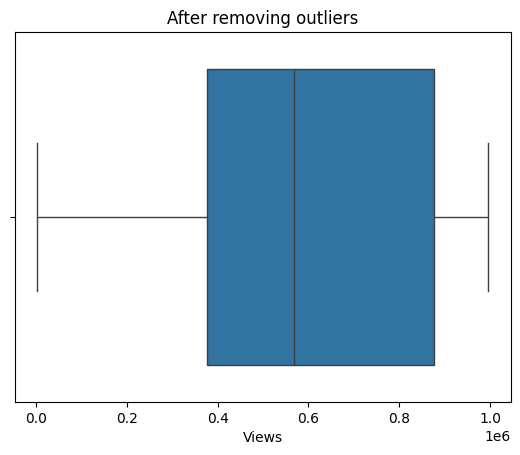

In [62]:
# before removing outliers
sns.boxplot(x='Views', data= df)
plt.title('Before removing outliers')
plt.show()

# IQR method
Q1 = df['Views'].quantile(0.25)
Q3 = df['Views'].quantile(0.75)
IQR = Q3 - Q1

filtered_df = df[(df['Views'] >= Q1 - 1.5 * IQR) & (df['Views'] <= Q3 + 1.5 * IQR)]

print('Original Shape', df.shape)
print('Filtered Shape', filtered_df.shape)

# after removing outliers
sns.boxplot(x='Views', data= filtered_df)
plt.title('After removing outliers')
plt.show()